In [ ]:
!pip install shap xgboost pandas scikit-learn matplotlib

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

print("Libraries installed successfully.")

Libraries installed successfully.


Dropped 5811 samples with NaN in target drug 'amikacin'.
Features shape after alignment and NaN handling: (2033, 3967)
Target labels shape after alignment and NaN handling: (2033,)
Target drug selected: amikacin


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:13:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Performance Report for amikacin:
              precision    recall  f1-score   support

         0.0       0.91      0.90      0.90       277
         1.0       0.79      0.80      0.80       130

    accuracy                           0.87       407
   macro avg       0.85      0.85      0.85       407
weighted avg       0.87      0.87      0.87       407


Generating SHAP Discovery Plot...


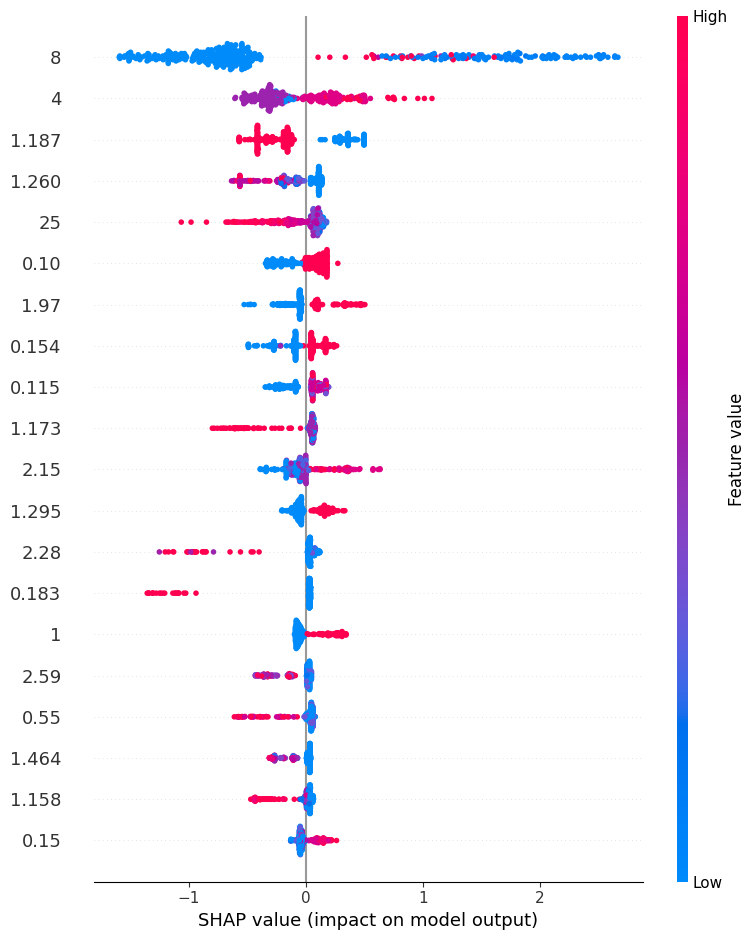

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. LOAD YOUR DATA
features_path = '/content/drive/MyDrive/Thesis_Trial/gene_data_19.csv'
labels_path = '/content/drive/MyDrive/Thesis_Trial/AllLabels.csv'

# Load features data, assuming the first column is the sample ID
X_raw = pd.read_csv(features_path).set_index(pd.read_csv(features_path).columns[0])

# Load labels data, assuming 'id' column is the sample ID
y_all_raw = pd.read_csv(labels_path).set_index('id')

# 2. PRE-PROCESSING
# Drop any 'Unnamed: 0' columns that might have been accidentally loaded
if 'Unnamed: 0' in X_raw.columns:
    X_raw = X_raw.drop(columns=['Unnamed: 0'])
if 'Unnamed: 0' in y_all_raw.columns:
    y_all_raw = y_all_raw.drop(columns=['Unnamed: 0'])

# Align X and y_all based on their sample IDs (index)
common_ids = X_raw.index.intersection(y_all_raw.index)
X = X_raw.loc[common_ids]
y_all = y_all_raw.loc[common_ids]

# Choose one drug for the trial
# <--- IMPORTANT: CHANGE 'amikacin' TO YOUR DRUG OF INTEREST (e.g., 'Isoniazid', 'capreomycin', 'ethambutol') --->
target_drug = 'amikacin'

if target_drug not in y_all.columns:
    raise ValueError(f"Target drug '{target_drug}' not found in labels data. Available drugs: {y_all.columns.tolist()}")

y = y_all[target_drug]

# Handle NaN values in the target drug column (samples with missing labels cannot be used for training)
initial_samples_count = len(y)
X = X.loc[y.dropna().index] # Ensure X aligns with filtered y
y = y.dropna()

print(f"Dropped {initial_samples_count - len(y)} samples with NaN in target drug '{target_drug}'.")

# Ensure y is numeric (float or int) for XGBoost
y = y.astype(float)

# Check for non-binary labels if this is intended for binary classification
unique_y_values = y.unique()
if not np.all(np.isin(unique_y_values, [0.0, 1.0])):
    print(f"Warning: Target variable '{target_drug}' contains values other than 0 or 1: {unique_y_values}. Ensure this is expected for your model.")

print(f"Features shape after alignment and NaN handling: {X.shape}")
print(f"Target labels shape after alignment and NaN handling: {y.shape}")
print(f"Target drug selected: {target_drug}")

# 3. TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. TRAIN XGBOOST MODEL
# We use scale_pos_weight because TB datasets are often imbalanced (more Susceptible than Resistant)
positive_samples = sum(y)
negative_samples = len(y) - positive_samples

if positive_samples == 0 or negative_samples == 0:
    print(f"Warning: Not enough positive ({positive_samples}) or negative ({negative_samples}) samples for the selected target drug. `scale_pos_weight` will be 1.")
    scale_pos_weight_val = 1 # Default to 1 if no positive or negative samples
else:
    scale_pos_weight_val = negative_samples / positive_samples

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_val,
    eval_metric='logloss',
    use_label_encoder=False # Suppress warning for deprecated use_label_encoder
)
model.fit(X_train, y_train)

# 5. EVALUATION
predictions = model.predict(X_test)
print(f"\nPerformance Report for {target_drug}:")
print(classification_report(y_test, predictions))

# 6. EXPLAINABLE AI (SHAP)
# This identifies which genes/SNPs from gene_data_19.csv are causing resistance
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("\nGenerating SHAP Discovery Plot...")
shap.summary_plot(shap_values, X_test)

Final dataset shape: (2033, 3967)
Target distribution:
amikacin
0.0    1460
1.0     573
Name: count, dtype: int64
Scale_pos_weight: 2.550218340611354


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:32:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.93      0.92       292
         1.0       0.82      0.77      0.80       115

    accuracy                           0.89       407
   macro avg       0.87      0.85      0.86       407
weighted avg       0.89      0.89      0.89       407

ROC-AUC Score: 0.9350208457415128

SHAP Feature Importance (Bar Plot):


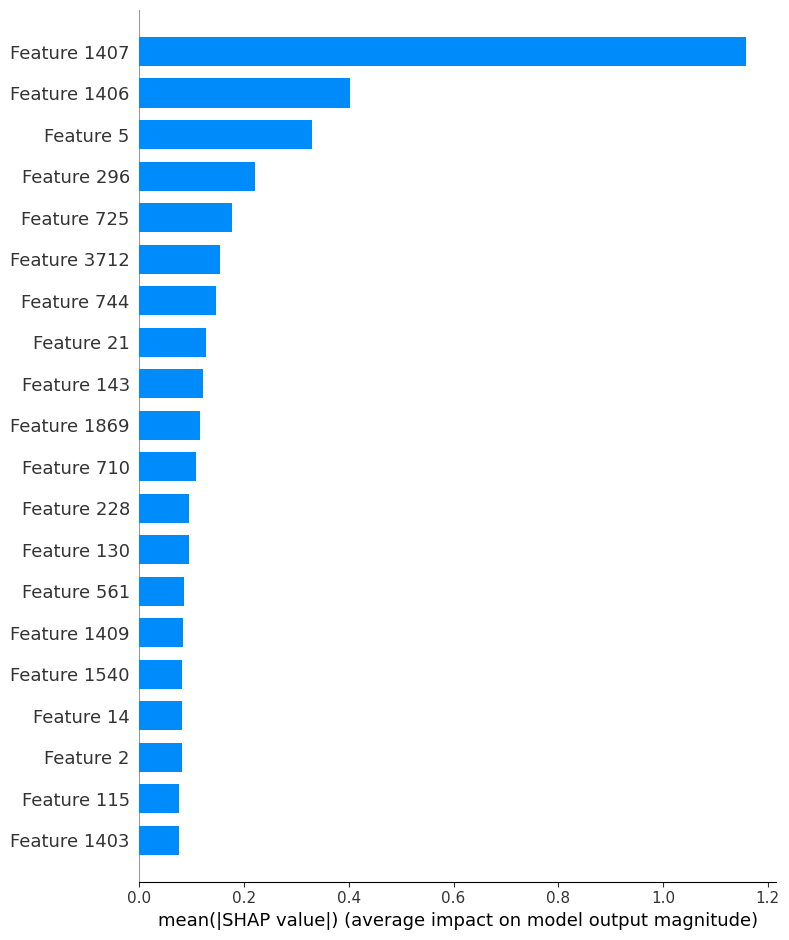


SHAP Detailed Impact Plot:


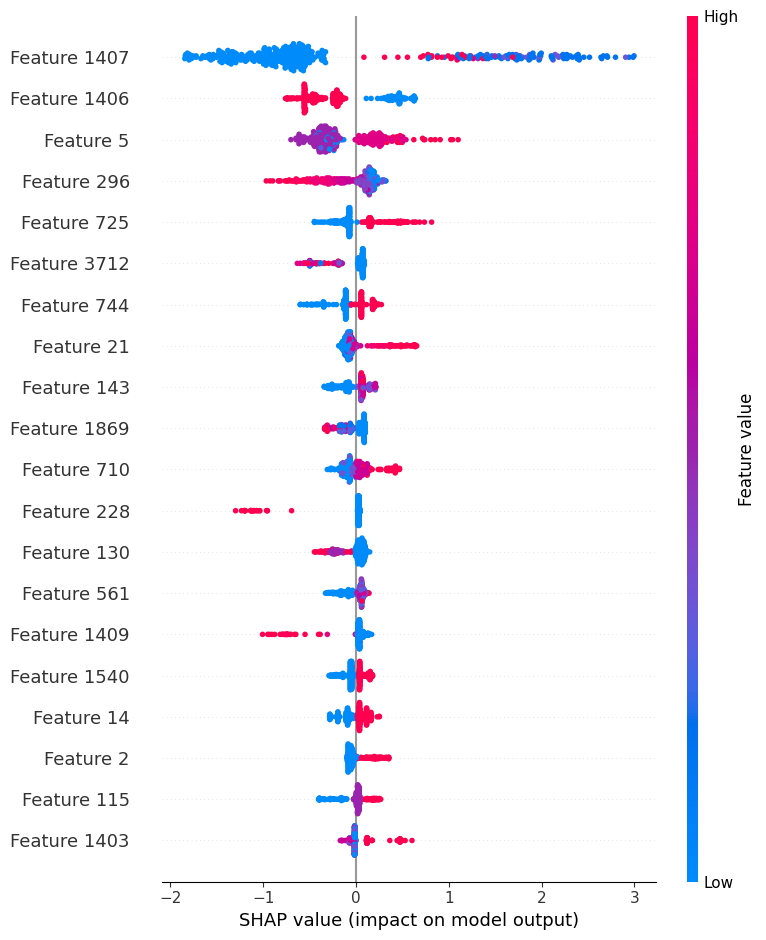

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# ==============================
# 1. LOAD DATA
# ==============================

features_path = '/content/drive/MyDrive/Thesis_Trial/gene_data_19.csv'
labels_path = '/content/drive/MyDrive/Thesis_Trial/AllLabels.csv'

# Load feature data (gene mutations)
X_raw = pd.read_csv(features_path)
X_raw = X_raw.set_index(X_raw.columns[0])  # first column = sample ID

# Load label data (drug resistance)
y_all_raw = pd.read_csv(labels_path).set_index('id')

# ==============================
# 2. CLEANING & ALIGNMENT
# ==============================

# Remove unwanted columns
if 'Unnamed: 0' in X_raw.columns:
    X_raw = X_raw.drop(columns=['Unnamed: 0'])

if 'Unnamed: 0' in y_all_raw.columns:
    y_all_raw = y_all_raw.drop(columns=['Unnamed: 0'])

# Match samples between features and labels
common_ids = X_raw.index.intersection(y_all_raw.index)

X = X_raw.loc[common_ids]
y_all = y_all_raw.loc[common_ids]

# ==============================
# 3. SELECT TARGET DRUG
# ==============================

target_drug = 'amikacin'   # 🔥 change this later if needed

if target_drug not in y_all.columns:
    raise ValueError(f"{target_drug} not found. Available: {y_all.columns.tolist()}")

y = y_all[target_drug]

# Remove samples with missing labels
X = X.loc[y.dropna().index]
y = y.dropna()

# Convert to numeric
y = y.astype(float)

print(f"Final dataset shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

# ==============================
# 4. TRAIN-TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# 5. OPTIONAL: SCALING
# ==============================
# XGBoost doesn't require scaling, but good practice

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 6. HANDLE CLASS IMBALANCE
# ==============================

positive = sum(y_train)
negative = len(y_train) - positive

if positive == 0 or negative == 0:
    scale_pos_weight_val = 1
else:
    scale_pos_weight_val = negative / positive

print(f"Scale_pos_weight: {scale_pos_weight_val}")

# ==============================
# 7. TRAIN MODEL (XGBoost)
# ==============================

model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_val,
    eval_metric='logloss',
    use_label_encoder=False
)

model.fit(X_train, y_train)

# ==============================
# 8. EVALUATION
# ==============================

pred = model.predict(X_test)
probs = model.predict_proba(X_test)[:,1]

print("\nClassification Report:")
print(classification_report(y_test, pred))

print("ROC-AUC Score:", roc_auc_score(y_test, probs))

# ==============================
# 9. SHAP EXPLAINABILITY
# ==============================

# SHAP Explainer (Tree-based)
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# 🔥 Feature importance plot (most important mutations)
print("\nSHAP Feature Importance (Bar Plot):")
shap.summary_plot(shap_values, X_test, plot_type="bar")

# 🔥 Detailed distribution plot
print("\nSHAP Detailed Impact Plot:")
shap.summary_plot(shap_values, X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

Logistic Regression Model

In [ ]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:,1]

print("\n🔹 Logistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))
print(classification_report(y_test, lr_pred))


🔹 Logistic Regression
Accuracy: 0.7862407862407862
ROC-AUC: 0.8176891006551519
              precision    recall  f1-score   support

         0.0       0.86      0.84      0.85       292
         1.0       0.62      0.64      0.63       115

    accuracy                           0.79       407
   macro avg       0.74      0.74      0.74       407
weighted avg       0.79      0.79      0.79       407



Random Forest Model

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

print("\n🔹 Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))
print(classification_report(y_test, rf_pred))


🔹 Random Forest
Accuracy: 0.8452088452088452
ROC-AUC: 0.8699672424061942
              precision    recall  f1-score   support

         0.0       0.86      0.94      0.90       292
         1.0       0.80      0.61      0.69       115

    accuracy                           0.85       407
   macro avg       0.83      0.77      0.79       407
weighted avg       0.84      0.85      0.84       407



XGBoost

In [ ]:
xgb_pred = model.predict(X_test)
xgb_prob = model.predict_proba(X_test)[:,1]

print("\n🔹 XGBoost")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))


🔹 XGBoost
Accuracy: 0.8894348894348895
ROC-AUC: 0.9350208457415128


**Ensemble Model (Voting Classifier)**

In [ ]:
voting_model = VotingClassifier(
    estimators=[
        ('lr', lr_model),
        ('rf', rf_model),
        ('xgb', model)
    ],
    voting='soft'   # use probabilities
)

voting_model.fit(X_train, y_train)

vote_pred = voting_model.predict(X_test)
vote_prob = voting_model.predict_proba(X_test)[:,1]

print("\n🔥 Voting Ensemble")
print("Accuracy:", accuracy_score(y_test, vote_pred))
print("ROC-AUC:", roc_auc_score(y_test, vote_prob))
print(classification_report(y_test, vote_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:40:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔥 Voting Ensemble
Accuracy: 0.8648648648648649
ROC-AUC: 0.9112269207861823
              precision    recall  f1-score   support

         0.0       0.89      0.93      0.91       292
         1.0       0.79      0.70      0.75       115

    accuracy                           0.86       407
   macro avg       0.84      0.82      0.83       407
weighted avg       0.86      0.86      0.86       407



**Final Comparison**

In [ ]:
print("\n====== MODEL COMPARISON ======")

print("LR Accuracy:", accuracy_score(y_test, lr_pred))
print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print("XGB Accuracy:", accuracy_score(y_test, xgb_pred))
print("Voting Accuracy:", accuracy_score(y_test, vote_pred))
# print("Stacking Accuracy:", accuracy_score(y_test, stack_pred))


====== MODEL COMPARISON ======
LR Accuracy: 0.7862407862407862
RF Accuracy: 0.8452088452088452
XGB Accuracy: 0.8894348894348895
Voting Accuracy: 0.8648648648648649


**SHAP on Random Forest (Best for ensemble explanation)**

🔥 SHAP for Random Forest (Ensemble proxy)


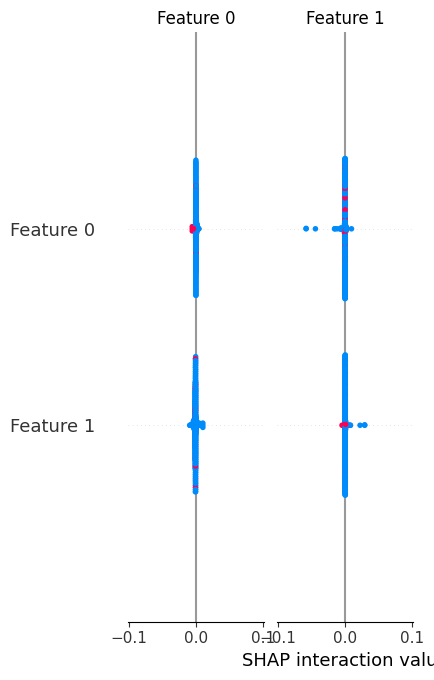

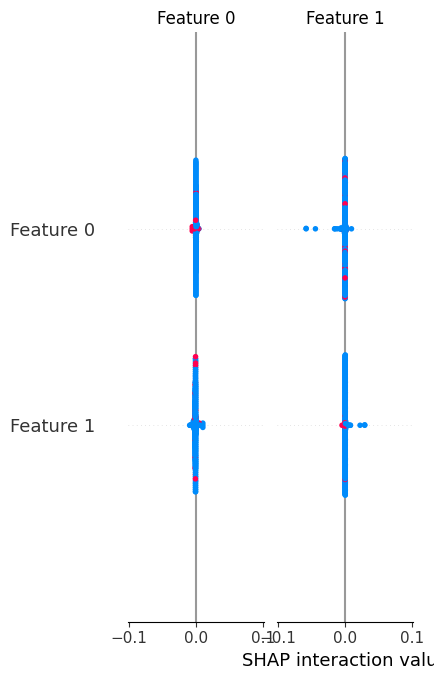

In [ ]:
import shap

# TreeExplainer works perfectly for RF
explainer_rf = shap.TreeExplainer(rf_model)

shap_values_rf = explainer_rf.shap_values(X_test)

print("🔥 SHAP for Random Forest (Ensemble proxy)")

# Feature importance
shap.summary_plot(shap_values_rf, X_test, plot_type="bar")

# Detailed impact
shap.summary_plot(shap_values_rf, X_test)